In [3]:
!git clone https://github.com/Atha1407/MediRent-Ai.git

Cloning into 'MediRent-Ai'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 43 (delta 15), reused 14 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 422.62 KiB | 4.27 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [5]:
import os

processed_path = "/content/MediRent-Ai/data/processed"

print("Processed files:")
print(os.listdir(processed_path))

Processed files:
['demand_model_comparison.csv', 'cleaned_medical_equipment_dataset.csv', 'feature_engineered_medical_equipment_dataset.csv', '.gitkeep', 'demand_prediction_model_dataset.csv', 'demand_prediction_dataset.csv']


In [6]:
import pandas as pd

file_path = "/content/MediRent-Ai/data/processed/feature_engineered_medical_equipment_dataset.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\nFirst 5 rows:")
display(df.head())

Shape: (3500, 46)

Columns:
1. Rental_ID
2. Customer_ID
3. Customer_Type
4. Area
5. Equipment
6. Equipment_Category
7. Rental_Duration_Days
8. Daily_Rate
9. Total_Rental_Amount_Original
10. Security_Deposit
11. Delivery_Charge
12. Maintenance_Cost
13. Payment_Mode
14. Rental_Status
15. Equipment_Condition
16. Booking_Date
17. Rental_Start_Date
18. Booking_Status
19. Cancellation_Status
20. Customer_Pincode
21. Equipment_Age_Years
22. Total_Inventory
23. Available_Units_At_Start
24. Customer_Pincode_Missing
25. Total_Rental_Amount
26. Rental_Year
27. Rental_Month
28. Rental_Quarter
29. Rental_DayOfWeek
30. Is_Weekend
31. Booking_Lead_Days
32. Rental_Week
33. Rental_Start_Month_Name
34. Equipment_Availability_Ratio
35. Maintenance_Days_Remaining
36. Maintenance_Overdue
37. Maintenance_Due_Within_30_Days
38. Rental_Extends_Beyond_Maintenance
39. Is_Cancelled
40. Unavailable_Units_At_Start
41. Customer_Previous_Rentals
42. Historical_Demand_Lag_1
43. Historical_Demand_Lag_2
44. Historical_

,Rental_ID,Customer_ID,Customer_Type,Area,Equipment,Equipment_Category,Rental_Duration_Days,Daily_Rate,Total_Rental_Amount_Original,Security_Deposit,...,Maintenance_Due_Within_30_Days,Rental_Extends_Beyond_Maintenance,Is_Cancelled,Unavailable_Units_At_Start,Customer_Previous_Rentals,Historical_Demand_Lag_1,Historical_Demand_Lag_2,Historical_Demand_Rolling_3M,Historical_Demand_Rolling_6M,Historical_Demand_Trend_2M
0,REN2537,CUST436,Clinic,Vishrantwadi,Commode Chair,Mobility Equipment,14,90,1260,1710,...,0.0,0.0,0,0,0,NaN,NaN,NaN,NaN,NaN
1,REN1858,CUST128,Individual Patient,Hinjawadi,Patient Monitor,Monitoring Equipment,5,660,3300,9900,...,0.0,0.0,0,0,0,NaN,NaN,NaN,NaN,NaN
2,REN1921,CUST418,Individual Patient,Chinchwad,CPAP Machine,Respiratory Equipment,45,380,17100,6840,...,0.0,0.0,0,0,0,NaN,NaN,NaN,NaN,NaN
3,REN1444,CUST316,Diagnostic Center,Aundh,Commode Chair,Mobility Equipment,14,90,1260,900,...,0.0,0.0,0,1,0,NaN,NaN,NaN,NaN,NaN
4,REN1441,CUST392,Clinic,Wakad,Walker,Mobility Equipment,14,70,980,1540,...,0.0,0.0,0,0,0,NaN,NaN,NaN,NaN,NaN


In [7]:
revenue_cols = [
    "Total_Rental_Amount_Original",
    "Total_Rental_Amount",
    "Daily_Rate",
    "Rental_Duration_Days",
    "Delivery_Charge",
    "Maintenance_Cost",
    "Rental_Status",
    "Booking_Status",
    "Cancellation_Status",
    "Is_Cancelled"
]

print("Revenue-related column summary:\n")

display(df[revenue_cols].describe(include="all").T)

print("\nMissing values:")
print(df[revenue_cols].isnull().sum())

print("\nRental Status:")
print(df["Rental_Status"].value_counts(dropna=False))

print("\nBooking Status:")
print(df["Booking_Status"].value_counts(dropna=False))

print("\nCancellation Status:")
print(df["Cancellation_Status"].value_counts(dropna=False))

Revenue-related column summary:



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Total_Rental_Amount_Original,3500.0,NaN,NaN,NaN,4132.822857,4510.005273,70.0,1197.5,2520.0,5200.0,47700.0
Total_Rental_Amount,3500.0,NaN,NaN,NaN,4149.061429,4571.87121,70.0,1197.5,2520.0,5200.0,47700.0
Daily_Rate,3500.0,NaN,NaN,NaN,321.757143,192.39146,60.0,160.0,320.0,410.0,1180.0
Rental_Duration_Days,3500.0,NaN,NaN,NaN,12.930286,10.511646,1.0,5.0,10.0,21.0,60.0
Delivery_Charge,3500.0,NaN,NaN,NaN,334.742857,151.905369,100.0,200.0,300.0,450.0,1000.0
Maintenance_Cost,3500.0,NaN,NaN,NaN,101.579429,159.158534,0.0,28.0,57.0,109.0,2300.0
Rental_Status,3500,3,Returned,3009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Booking_Status,3500,3,Completed,3009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cancellation_Status,3500,2,Not Cancelled,3355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Is_Cancelled,3500.0,NaN,NaN,NaN,0.041429,0.199308,0.0,0.0,0.0,0.0,1.0



Missing values:
Total_Rental_Amount_Original    0
Total_Rental_Amount             0
Daily_Rate                      0
Rental_Duration_Days            0
Delivery_Charge                 0
Maintenance_Cost                0
Rental_Status                   0
Booking_Status                  0
Cancellation_Status             0
Is_Cancelled                    0
dtype: int64

Rental Status:
Rental_Status
Returned     3009
Active        346
Cancelled     145
Name: count, dtype: int64

Booking Status:
Booking_Status
Completed    3009
Confirmed     346
Cancelled     145
Name: count, dtype: int64

Cancellation Status:
Cancellation_Status
Not Cancelled    3355
Cancelled         145
Name: count, dtype: int64


In [8]:
# Compare the two possible revenue columns

comparison = df[
    ["Total_Rental_Amount_Original", "Total_Rental_Amount"]
].copy()

comparison["Difference"] = (
    comparison["Total_Rental_Amount"]
    - comparison["Total_Rental_Amount_Original"]
)

print("Number of rows where values differ:",
      (comparison["Difference"] != 0).sum())

print("\nDifference statistics:")
display(comparison["Difference"].describe())

print("\nRows where they differ:")
display(
    comparison[comparison["Difference"] != 0].head(10)
)

Number of rows where values differ: 10

Difference statistics:


,Difference
count,3500.000000
mean,16.238571
std,452.701903
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,20580.000000



Rows where they differ:


,Total_Rental_Amount_Original,Total_Rental_Amount,Difference
495,2520,3780,1260
975,3600,7200,3600
1023,20580,41160,20580
1414,10600,21200,10600
1492,1890,2835,945
1517,2700,4050,1350
1696,23400,35100,11700
1983,700,1050,350
2908,5100,10200,5100
3386,1350,2700,1350


In [9]:
cols = [
    "Rental_ID",
    "Rental_Status",
    "Booking_Status",
    "Cancellation_Status",
    "Rental_Duration_Days",
    "Daily_Rate",
    "Total_Rental_Amount_Original",
    "Total_Rental_Amount"
]

display(df[df["Total_Rental_Amount"] != df["Total_Rental_Amount_Original"]][cols])

,Rental_ID,Rental_Status,Booking_Status,Cancellation_Status,Rental_Duration_Days,Daily_Rate,Total_Rental_Amount_Original,Total_Rental_Amount
495,REN0972,Returned,Completed,Not Cancelled,14,270,2520,3780
975,REN2788,Returned,Completed,Not Cancelled,20,360,3600,7200
1023,REN2203,Returned,Completed,Not Cancelled,42,980,20580,41160
1414,REN2387,Returned,Completed,Not Cancelled,20,1060,10600,21200
1492,REN2222,Returned,Completed,Not Cancelled,7,405,1890,2835
1517,REN1518,Returned,Completed,Not Cancelled,5,810,2700,4050
1696,REN2638,Returned,Completed,Not Cancelled,45,780,23400,35100
1983,REN3132,Returned,Completed,Not Cancelled,10,105,700,1050
2908,REN0217,Returned,Completed,Not Cancelled,60,170,5100,10200
3386,REN2402,Returned,Completed,Not Cancelled,6,450,1350,2700


In [10]:
df["Calculated_Amount"] = (
    df["Rental_Duration_Days"] * df["Daily_Rate"]
)

print("Rows matching Total_Rental_Amount:")
print(
    (df["Total_Rental_Amount"] == df["Calculated_Amount"]).sum(),
    "out of", len(df)
)

print("\nRows matching Original amount:")
print(
    (df["Total_Rental_Amount_Original"] == df["Calculated_Amount"]).sum(),
    "out of", len(df)
)

Rows matching Total_Rental_Amount:
3500 out of 3500

Rows matching Original amount:
3490 out of 3500


In [11]:
print("Start date:", df["Rental_Start_Date"].min())
print("End date:", df["Rental_Start_Date"].max())
print("Number of months:", df["Rental_Start_Date"].nunique())

Start date: 2024-01-01
End date: 2026-07-31
Number of months: 895


In [12]:
df["Month"] = pd.to_datetime(df["Rental_Start_Date"]).dt.to_period("M")

monthly_revenue = df.groupby("Month")["Total_Rental_Amount"].sum()

print("Number of months:", len(monthly_revenue))
print("\nMonthly revenue:")
print(monthly_revenue)

Number of months: 31

Monthly revenue:
Month
2024-01    285690
2024-02    393090
2024-03    331460
2024-04    450910
2024-05    425970
2024-06    366580
2024-07    430810
2024-08    423530
2024-09    327220
2024-10    382190
2024-11    289430
2024-12    338120
2025-01    448710
2025-02    308870
2025-03    411890
2025-04    429190
2025-05    335965
2025-06    358340
2025-07    455540
2025-08    397280
2025-09    312400
2025-10    368800
2025-11    288960
2025-12    459660
2026-01    326370
2026-02    736740
2026-03    925490
2026-04    820050
2026-05    831160
2026-06    871930
2026-07    989370
Freq: M, Name: Total_Rental_Amount, dtype: int64


In [13]:
category_revenue = (
    df.groupby("Equipment_Category")["Total_Rental_Amount"]
      .agg(["count", "sum", "mean"])
      .sort_values("sum", ascending=False)
)

display(category_revenue)

,count,sum,mean
Equipment_Category,,,
Respiratory Equipment,1042,4268005,4095.974088
Patient Care Equipment,738,3602490,4881.422764
Critical Care Equipment,203,1593030,7847.438424
Monitoring Equipment,192,1584580,8253.020833
Mobility Equipment,765,1269510,1659.490196
Surgical Equipment,401,1112910,2775.336658
Diagnostic Equipment,159,1091190,6862.830189


In [14]:
monthly = df.groupby("Month").agg(
    Rentals=("Rental_ID", "count"),
    Revenue=("Total_Rental_Amount", "sum")
)

print(monthly)

         Rentals  Revenue
Month                    
2024-01       70   285690
2024-02       93   393090
2024-03       72   331460
2024-04      101   450910
2024-05      112   425970
2024-06       93   366580
2024-07      102   430810
2024-08      102   423530
2024-09       83   327220
2024-10       87   382190
2024-11       75   289430
2024-12       76   338120
2025-01       96   448710
2025-02       76   308870
2025-03      102   411890
2025-04       97   429190
2025-05       94   335965
2025-06       89   358340
2025-07      102   455540
2025-08       92   397280
2025-09       88   312400
2025-10       72   368800
2025-11       68   288960
2025-12      102   459660
2026-01       92   326370
2026-02      184   736740
2026-03      227   925490
2026-04      200   820050
2026-05      221   831160
2026-06      196   871930
2026-07      236   989370


In [15]:
revenue_data = (
    df.groupby("Month")
      .agg(
          Monthly_Rentals=("Rental_ID", "count"),
          Monthly_Revenue=("Total_Rental_Amount", "sum")
      )
      .reset_index()
)

print(revenue_data.shape)
display(revenue_data.head())

(31, 3)


,Month,Monthly_Rentals,Monthly_Revenue
0,2024-01,70,285690
1,2024-02,93,393090
2,2024-03,72,331460
3,2024-04,101,450910
4,2024-05,112,425970


In [16]:
revenue_data["Year"] = revenue_data["Month"].dt.year
revenue_data["Month_Number"] = revenue_data["Month"].dt.month
revenue_data["Quarter"] = revenue_data["Month"].dt.quarter

display(revenue_data.head())

,Month,Monthly_Rentals,Monthly_Revenue,Year,Month_Number,Quarter
0,2024-01,70,285690,2024,1,1
1,2024-02,93,393090,2024,2,1
2,2024-03,72,331460,2024,3,1
3,2024-04,101,450910,2024,4,2
4,2024-05,112,425970,2024,5,2


In [17]:
revenue_data["Previous_Month_Revenue"] = (
    revenue_data["Monthly_Revenue"].shift(1)
)

print(revenue_data.head())

     Month  Monthly_Rentals  Monthly_Revenue  Year  Month_Number  Quarter  \
0  2024-01               70           285690  2024             1        1   
1  2024-02               93           393090  2024             2        1   
2  2024-03               72           331460  2024             3        1   
3  2024-04              101           450910  2024             4        2   
4  2024-05              112           425970  2024             5        2   

   Previous_Month_Revenue  
0                     NaN  
1                285690.0  
2                393090.0  
3                331460.0  
4                450910.0  


In [18]:
revenue_data["Rolling_3M_Revenue"] = (
    revenue_data["Monthly_Revenue"]
    .shift(1)
    .rolling(3)
    .mean()
)

print(revenue_data)

      Month  Monthly_Rentals  Monthly_Revenue  Year  Month_Number  Quarter  \
0   2024-01               70           285690  2024             1        1   
1   2024-02               93           393090  2024             2        1   
2   2024-03               72           331460  2024             3        1   
3   2024-04              101           450910  2024             4        2   
4   2024-05              112           425970  2024             5        2   
5   2024-06               93           366580  2024             6        2   
6   2024-07              102           430810  2024             7        3   
7   2024-08              102           423530  2024             8        3   
8   2024-09               83           327220  2024             9        3   
9   2024-10               87           382190  2024            10        4   
10  2024-11               75           289430  2024            11        4   
11  2024-12               76           338120  2024            1

In [19]:
revenue_data["Previous_Month_Rentals"] = (
    revenue_data["Monthly_Rentals"].shift(1)
)

print(revenue_data.head())

     Month  Monthly_Rentals  Monthly_Revenue  Year  Month_Number  Quarter  \
0  2024-01               70           285690  2024             1        1   
1  2024-02               93           393090  2024             2        1   
2  2024-03               72           331460  2024             3        1   
3  2024-04              101           450910  2024             4        2   
4  2024-05              112           425970  2024             5        2   

   Previous_Month_Revenue  Rolling_3M_Revenue  Previous_Month_Rentals  
0                     NaN                 NaN                     NaN  
1                285690.0                 NaN                    70.0  
2                393090.0                 NaN                    93.0  
3                331460.0       336746.666667                    72.0  
4                450910.0       391820.000000                   101.0  


In [20]:
print(revenue_data.isnull().sum())

Month                     0
Monthly_Rentals           0
Monthly_Revenue           0
Year                      0
Month_Number              0
Quarter                   0
Previous_Month_Revenue    1
Rolling_3M_Revenue        3
Previous_Month_Rentals    1
dtype: int64


In [21]:
print("Duplicate months:", revenue_data["Month"].duplicated().sum())

Duplicate months: 0


In [22]:
revenue_model_data = revenue_data.dropna().reset_index(drop=True)

print("Shape:", revenue_model_data.shape)
print("\nFirst row:")
print(revenue_model_data.head(1))

Shape: (28, 9)

First row:
     Month  Monthly_Rentals  Monthly_Revenue  Year  Month_Number  Quarter  \
0  2024-04              101           450910  2024             4        2   

   Previous_Month_Revenue  Rolling_3M_Revenue  Previous_Month_Rentals  
0                331460.0       336746.666667                    72.0  


In [23]:
print(revenue_model_data.tail(8)[
    ["Month", "Monthly_Rentals", "Monthly_Revenue"]
])

      Month  Monthly_Rentals  Monthly_Revenue
20  2025-12              102           459660
21  2026-01               92           326370
22  2026-02              184           736740
23  2026-03              227           925490
24  2026-04              200           820050
25  2026-05              221           831160
26  2026-06              196           871930
27  2026-07              236           989370


In [24]:
train = revenue_model_data.iloc[:-8].copy()
test = revenue_model_data.iloc[-8:].copy()

print("Train:", train.shape)
print("Train period:", train["Month"].min(), "to", train["Month"].max())

print("\nTest:", test.shape)
print("Test period:", test["Month"].min(), "to", test["Month"].max())

Train: (20, 9)
Train period: 2024-04 to 2025-11

Test: (8, 9)
Test period: 2025-12 to 2026-07


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_true = test["Monthly_Revenue"]
y_pred = test["Previous_Month_Revenue"]

print("Baseline Results")
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2:", r2_score(y_true, y_pred))

Baseline Results
MAE: 147233.75
RMSE: 186289.48765966372
R2: 0.2659145983304714


In [26]:
features = [
    "Year",
    "Month_Number",
    "Quarter",
    "Previous_Month_Revenue",
    "Rolling_3M_Revenue",
    "Previous_Month_Rentals"
]

X_train = train[features]
y_train = train["Monthly_Revenue"]

X_test = test[features]
y_test = test["Monthly_Revenue"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nFeatures:")
print(features)

X_train shape: (20, 6)
X_test shape: (8, 6)

Features:
['Year', 'Month_Number', 'Quarter', 'Previous_Month_Revenue', 'Rolling_3M_Revenue', 'Previous_Month_Rentals']


In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully.")
print("Predictions:", rf_pred)

Random Forest trained successfully.
Predictions: [340178.9  382316.3  392867.2  389242.35 391737.55 389206.8  388678.3
 393450.1 ]


In [28]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest Results
MAE: 375623.13749999995
RMSE: 416929.6530944107
R2: -2.6770154925664746


In [29]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost trained successfully.")
print("Predictions:", xgb_pred)

XGBoost trained successfully.
Predictions: [348785.2  399740.4  421332.72 380414.75 391137.3  391137.3  381909.56
 383564.8 ]


In [30]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

XGBoost Results
MAE: 376186.09375
RMSE: 418176.27425763884
R2: -2.6990370750427246


In [31]:
comparison = pd.DataFrame({
    "Model": [
        "Previous-Month Baseline",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        147233.75,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        186289.49,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        0.2659,
        rf_r2,
        xgb_r2
    ]
})

print(comparison)

                     Model           MAE           RMSE        R2
0  Previous-Month Baseline  147233.75000  186289.490000  0.265900
1            Random Forest  375623.13750  416929.653094 -2.677015
2                  XGBoost  376186.09375  418176.274258 -2.699037


In [32]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

print("Ridge trained successfully.")
print("Predictions:", ridge_pred)

Ridge trained successfully.
Predictions: [299858.29708578 396537.89388191 419595.24989517 338115.60991156
 358806.5854158  393433.33990104 393972.7266939  362028.18679184]


In [33]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Results")
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)
print("R2:", ridge_r2)

Ridge Results
MAE: 392344.73727335315
RMSE: 433359.06105692504
R2: -2.972515992228103


In [34]:
results = test[["Month", "Monthly_Revenue", "Previous_Month_Revenue"]].copy()

results["Random_Forest_Prediction"] = rf_pred
results["XGBoost_Prediction"] = xgb_pred
results["Ridge_Prediction"] = ridge_pred

print(results.to_string(index=False))

  Month  Monthly_Revenue  Previous_Month_Revenue  Random_Forest_Prediction  XGBoost_Prediction  Ridge_Prediction
2025-12           459660                288960.0                 340178.90        348785.18750     299858.297086
2026-01           326370                459660.0                 382316.30        399740.40625     396537.893882
2026-02           736740                326370.0                 392867.20        421332.71875     419595.249895
2026-03           925490                736740.0                 389242.35        380414.75000     338115.609912
2026-04           820050                925490.0                 391737.55        391137.31250     358806.585416
2026-05           831160                820050.0                 389206.80        391137.31250     393433.339901
2026-06           871930                831160.0                 388678.30        381909.56250     393972.726694
2026-07           989370                871930.0                 393450.10        383564.81250  

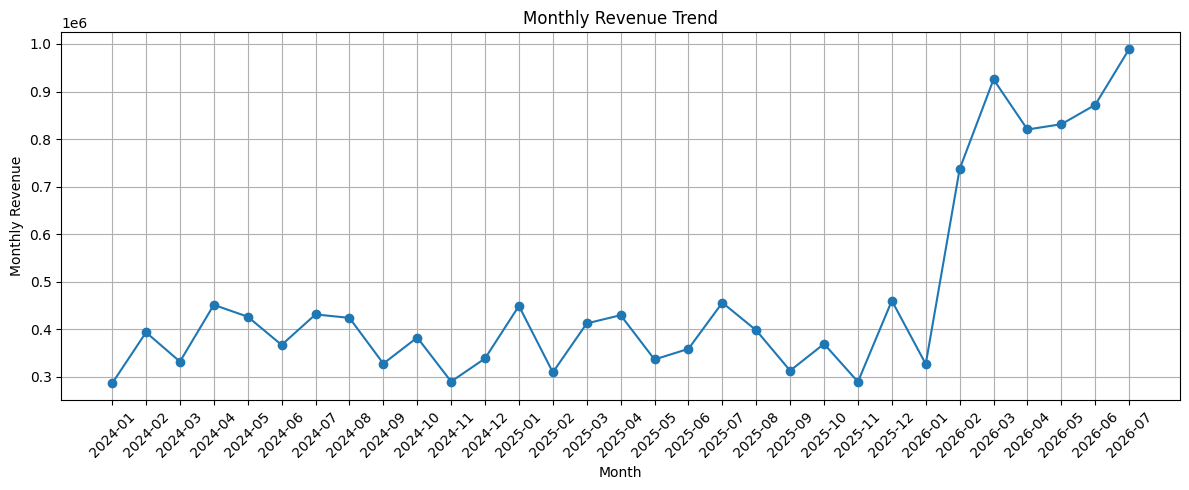

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    revenue_data["Month"].astype(str),
    revenue_data["Monthly_Revenue"],
    marker="o"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Monthly Revenue")
plt.title("Monthly Revenue Trend")
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
print(
    revenue_data[
        ["Month", "Monthly_Rentals", "Monthly_Revenue"]
    ].tail(12).to_string(index=False)
)

  Month  Monthly_Rentals  Monthly_Revenue
2025-08               92           397280
2025-09               88           312400
2025-10               72           368800
2025-11               68           288960
2025-12              102           459660
2026-01               92           326370
2026-02              184           736740
2026-03              227           925490
2026-04              200           820050
2026-05              221           831160
2026-06              196           871930
2026-07              236           989370


In [37]:
revenue_data["Average_Revenue_Per_Rental"] = (
    revenue_data["Monthly_Revenue"] / revenue_data["Monthly_Rentals"]
)

print(
    revenue_data[
        ["Month", "Monthly_Rentals", "Monthly_Revenue", "Average_Revenue_Per_Rental"]
    ].tail(12).to_string(index=False)
)

  Month  Monthly_Rentals  Monthly_Revenue  Average_Revenue_Per_Rental
2025-08               92           397280                 4318.260870
2025-09               88           312400                 3550.000000
2025-10               72           368800                 5122.222222
2025-11               68           288960                 4249.411765
2025-12              102           459660                 4506.470588
2026-01               92           326370                 3547.500000
2026-02              184           736740                 4004.021739
2026-03              227           925490                 4077.048458
2026-04              200           820050                 4100.250000
2026-05              221           831160                 3760.904977
2026-06              196           871930                 4448.622449
2026-07              236           989370                 4192.245763


In [38]:
train_avg_revenue_per_rental = (
    train["Monthly_Revenue"] / train["Monthly_Rentals"]
)

print("Training Average Revenue per Rental")
print("Mean:", train_avg_revenue_per_rental.mean())
print("Median:", train_avg_revenue_per_rental.median())
print("Min:", train_avg_revenue_per_rental.min())
print("Max:", train_avg_revenue_per_rental.max())

Training Average Revenue per Rental
Mean: 4186.802651215859
Median: 4187.941176470588
Min: 3550.0
Max: 5122.222222222223


In [39]:
avg_revenue_per_rental = train_avg_revenue_per_rental.mean()

volume_pred = (
    test["Previous_Month_Rentals"] * avg_revenue_per_rental
)

volume_mae = mean_absolute_error(y_test, volume_pred)
volume_rmse = np.sqrt(mean_squared_error(y_test, volume_pred))
volume_r2 = r2_score(y_test, volume_pred)

print("Volume-Based Revenue Results")
print("Average Revenue per Rental:", avg_revenue_per_rental)
print("MAE:", volume_mae)
print("RMSE:", volume_rmse)
print("R2:", volume_r2)

Volume-Based Revenue Results
Average Revenue per Rental: 4186.802651215859
MAE: 142622.3195944163
RMSE: 172030.31032991147
R2: 0.37399206732062784


In [40]:
comparison = pd.DataFrame({
    "Model": [
        "Previous-Month Revenue",
        "Random Forest",
        "XGBoost",
        "Ridge",
        "Volume-Based Revenue"
    ],
    "MAE": [
        147233.75,
        rf_mae,
        xgb_mae,
        ridge_mae,
        volume_mae
    ],
    "RMSE": [
        186289.49,
        rf_rmse,
        xgb_rmse,
        ridge_rmse,
        volume_rmse
    ],
    "R2": [
        0.2659,
        rf_r2,
        xgb_r2,
        ridge_r2,
        volume_r2
    ]
})

print(comparison)

                    Model            MAE           RMSE        R2
0  Previous-Month Revenue  147233.750000  186289.490000  0.265900
1           Random Forest  375623.137500  416929.653094 -2.677015
2                 XGBoost  376186.093750  418176.274258 -2.699037
3                   Ridge  392344.737273  433359.061057 -2.972516
4    Volume-Based Revenue  142622.319594  172030.310330  0.373992


In [41]:
demand_comparison = pd.read_csv(
    "/content/MediRent-Ai/data/processed/demand_model_comparison.csv"
)

print(demand_comparison)

                     Model       MAE      RMSE        R2
0  Previous-Month Baseline  4.589286  5.885818  0.459513
1         Ridge Regression  5.947332  7.682255  0.079235
2    Ridge - Demand Change  6.033626  7.743887  0.064402


In [42]:
demand_data = pd.read_csv(
    "/content/MediRent-Ai/data/processed/demand_prediction_dataset.csv"
)

print("Shape:", demand_data.shape)
print("\nColumns:")
print(demand_data.columns.tolist())

print("\nLast 20 rows:")
print(demand_data.tail(20).to_string(index=False))


Shape: (496, 11)

Columns:
['Equipment', 'Equipment_Category', 'Year', 'Month_Number', 'Quarter', 'Historical_Demand_Lag_1', 'Historical_Demand_Lag_2', 'Historical_Demand_Rolling_3M', 'Historical_Demand_Rolling_6M', 'Historical_Demand_Trend_2M', 'Monthly_Demand']

Last 20 rows:
 Equipment Equipment_Category  Year  Month_Number  Quarter  Historical_Demand_Lag_1  Historical_Demand_Lag_2  Historical_Demand_Rolling_3M  Historical_Demand_Rolling_6M  Historical_Demand_Trend_2M  Monthly_Demand
Wheelchair Mobility Equipment  2024            12        4                      9.0                     17.0                     12.000000                     13.166667                        -8.0               8
Wheelchair Mobility Equipment  2025             1        1                      8.0                      9.0                     11.333333                     11.666667                        -1.0               9
Wheelchair Mobility Equipment  2025             2        1                      9.

In [43]:
monthly_demand = (
    demand_data
    .groupby(["Year", "Month_Number"])["Monthly_Demand"]
    .sum()
    .reset_index()
)

monthly_demand["Month"] = pd.to_datetime(
    monthly_demand["Year"].astype(str)
    + "-"
    + monthly_demand["Month_Number"].astype(str)
    + "-01"
).dt.to_period("M")

monthly_demand["Previous_Month_Demand"] = (
    monthly_demand["Monthly_Demand"].shift(1)
)

print(monthly_demand.tail(12).to_string(index=False))

 Year  Month_Number  Monthly_Demand   Month  Previous_Month_Demand
 2025             8              92 2025-08                  102.0
 2025             9              88 2025-09                   92.0
 2025            10              72 2025-10                   88.0
 2025            11              68 2025-11                   72.0
 2025            12             102 2025-12                   68.0
 2026             1              92 2026-01                  102.0
 2026             2             184 2026-02                   92.0
 2026             3             227 2026-03                  184.0
 2026             4             200 2026-04                  227.0
 2026             5             221 2026-05                  200.0
 2026             6             196 2026-06                  221.0
 2026             7             236 2026-07                  196.0


In [44]:
revenue_test = test[[
    "Month",
    "Monthly_Revenue"
]].copy()

revenue_test = revenue_test.merge(
    monthly_demand[["Month", "Previous_Month_Demand"]],
    on="Month",
    how="left"
)

revenue_test["Predicted_Revenue"] = (
    revenue_test["Previous_Month_Demand"]
    * avg_revenue_per_rental
)

print(revenue_test.to_string(index=False))

  Month  Monthly_Revenue  Previous_Month_Demand  Predicted_Revenue
2025-12           459660                   68.0      284702.580283
2026-01           326370                  102.0      427053.870424
2026-02           736740                   92.0      385185.843912
2026-03           925490                  184.0      770371.687824
2026-04           820050                  227.0      950404.201826
2026-05           831160                  200.0      837360.530243
2026-06           871930                  221.0      925283.385919
2026-07           989370                  196.0      820613.319638


In [45]:
pipeline_mae = mean_absolute_error(
    revenue_test["Monthly_Revenue"],
    revenue_test["Predicted_Revenue"]
)

pipeline_rmse = np.sqrt(
    mean_squared_error(
        revenue_test["Monthly_Revenue"],
        revenue_test["Predicted_Revenue"]
    )
)

pipeline_r2 = r2_score(
    revenue_test["Monthly_Revenue"],
    revenue_test["Predicted_Revenue"]
)

print("Demand → Revenue Pipeline Results")
print("MAE:", pipeline_mae)
print("RMSE:", pipeline_rmse)
print("R2:", pipeline_r2)

Demand → Revenue Pipeline Results
MAE: 142622.3195944163
RMSE: 172030.31032991147
R2: 0.37399206732062784


In [46]:
final_results = revenue_test[
    ["Month", "Monthly_Revenue", "Predicted_Revenue"]
].copy()

final_results["Error"] = (
    final_results["Monthly_Revenue"]
    - final_results["Predicted_Revenue"]
)

final_results["Absolute_Error"] = final_results["Error"].abs()

print(final_results.to_string(index=False))

  Month  Monthly_Revenue  Predicted_Revenue          Error  Absolute_Error
2025-12           459660      284702.580283  174957.419717   174957.419717
2026-01           326370      427053.870424 -100683.870424   100683.870424
2026-02           736740      385185.843912  351554.156088   351554.156088
2026-03           925490      770371.687824  155118.312176   155118.312176
2026-04           820050      950404.201826 -130354.201826   130354.201826
2026-05           831160      837360.530243   -6200.530243     6200.530243
2026-06           871930      925283.385919  -53353.385919    53353.385919
2026-07           989370      820613.319638  168756.680362   168756.680362


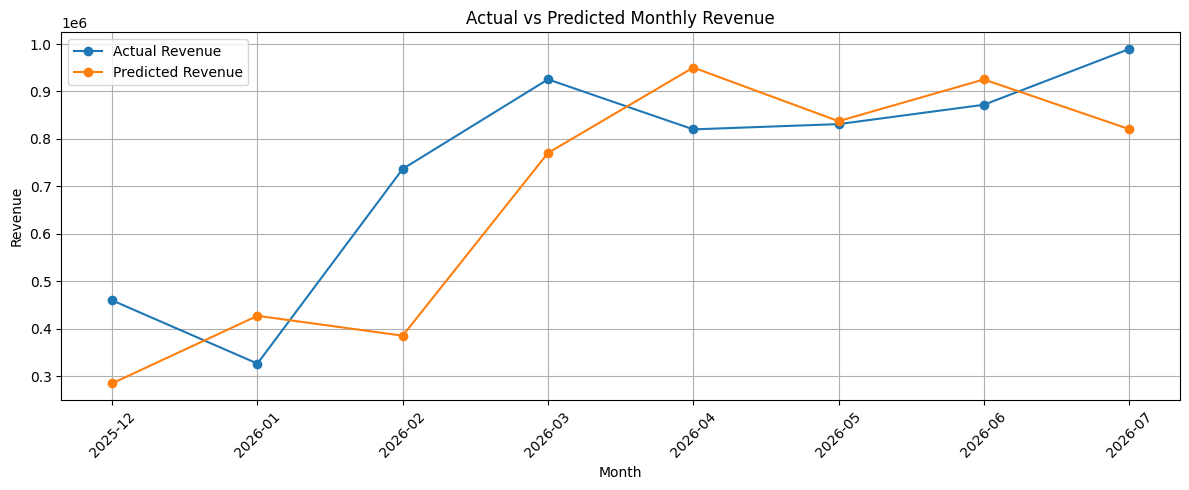

In [47]:
plt.figure(figsize=(12, 5))

plt.plot(
    final_results["Month"].astype(str),
    final_results["Monthly_Revenue"],
    marker="o",
    label="Actual Revenue"
)

plt.plot(
    final_results["Month"].astype(str),
    final_results["Predicted_Revenue"],
    marker="o",
    label="Predicted Revenue"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Actual vs Predicted Monthly Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
# Final revenue prediction results
final_revenue_predictions = final_results.copy()

# Save predictions
predictions_path = (
    "/content/MediRent-Ai/data/processed/revenue_predictions.csv"
)

final_revenue_predictions.to_csv(
    predictions_path,
    index=False
)

# Save model metrics
revenue_metrics = pd.DataFrame({
    "Model": [
        "Previous-Month Revenue",
        "Random Forest",
        "XGBoost",
        "Ridge",
        "Demand-Based Revenue"
    ],
    "MAE": [
        147233.75,
        rf_mae,
        xgb_mae,
        ridge_mae,
        pipeline_mae
    ],
    "RMSE": [
        186289.49,
        rf_rmse,
        xgb_rmse,
        ridge_rmse,
        pipeline_rmse
    ],
    "R2": [
        0.2659,
        rf_r2,
        xgb_r2,
        ridge_r2,
        pipeline_r2
    ]
})

metrics_path = (
    "/content/MediRent-Ai/data/processed/revenue_model_comparison.csv"
)

revenue_metrics.to_csv(
    metrics_path,
    index=False
)

print("Files saved successfully.")
print("\nPredictions:", predictions_path)
print("Metrics:", metrics_path)

print("\nFinal Predictions:")
print(final_revenue_predictions.to_string(index=False))

Files saved successfully.

Predictions: /content/MediRent-Ai/data/processed/revenue_predictions.csv
Metrics: /content/MediRent-Ai/data/processed/revenue_model_comparison.csv

Final Predictions:
  Month  Monthly_Revenue  Predicted_Revenue          Error  Absolute_Error
2025-12           459660      284702.580283  174957.419717   174957.419717
2026-01           326370      427053.870424 -100683.870424   100683.870424
2026-02           736740      385185.843912  351554.156088   351554.156088
2026-03           925490      770371.687824  155118.312176   155118.312176
2026-04           820050      950404.201826 -130354.201826   130354.201826
2026-05           831160      837360.530243   -6200.530243     6200.530243
2026-06           871930      925283.385919  -53353.385919    53353.385919
2026-07           989370      820613.319638  168756.680362   168756.680362


In [49]:
import os
import pandas as pd

predictions_path = "/content/MediRent-Ai/data/processed/revenue_predictions.csv"
metrics_path = "/content/MediRent-Ai/data/processed/revenue_model_comparison.csv"

print("Predictions file exists:", os.path.exists(predictions_path))
print("Metrics file exists:", os.path.exists(metrics_path))

print("\nRevenue Predictions:")
print(pd.read_csv(predictions_path))

print("\nModel Comparison:")
print(pd.read_csv(metrics_path))

Predictions file exists: True
Metrics file exists: True

Revenue Predictions:
     Month  Monthly_Revenue  Predicted_Revenue          Error  Absolute_Error
0  2025-12           459660      284702.580283  174957.419717   174957.419717
1  2026-01           326370      427053.870424 -100683.870424   100683.870424
2  2026-02           736740      385185.843912  351554.156088   351554.156088
3  2026-03           925490      770371.687824  155118.312176   155118.312176
4  2026-04           820050      950404.201826 -130354.201826   130354.201826
5  2026-05           831160      837360.530243   -6200.530243     6200.530243
6  2026-06           871930      925283.385919  -53353.385919    53353.385919
7  2026-07           989370      820613.319638  168756.680362   168756.680362

Model Comparison:
                    Model            MAE           RMSE        R2
0  Previous-Month Revenue  147233.750000  186289.490000  0.265900
1           Random Forest  375623.137500  416929.653094 -2.677015
2  

In [50]:
!cd /content/MediRent-Ai && git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	data/processed/revenue_model_comparison.csv
	data/processed/revenue_predictions.csv

nothing added to commit but untracked files present (use "git add" to track)


In [51]:
!cd /content/MediRent-Ai && git status --short

?? data/processed/revenue_model_comparison.csv
?? data/processed/revenue_predictions.csv


In [52]:
!find /content -name "04_Revenue_Prediction.ipynb" -type f